# E4
No existe una variable objetivo, pero `median_house_value` no debe utilizarse para ajustar transformaciones, reducir dimensionalidad ni construir clusters. La usaremos solo al final para interpretar los perfiles obtenidos.

## Imports y configuracion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Mision 1: Preparacion del conjunto de datos

In [2]:
df_original = pd.read_csv("data/E4_datos.csv")

display(df_original.head())
display(df_original.info())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


None

In [3]:
display(df_original.isna().sum().rename("faltantes"))
display(df_original.describe(include="all"))

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
Name: faltantes, dtype: int64

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


Para representar mejor los distritos, construiremos variables derivadas por hogar o por habitacion.

`median_house_value` se excluye de la matriz usada para clustering, porque solo puede utilizarse despues, para interpretar los perfiles.

In [4]:
def add_derived_features(data):
    data = data.copy()
    data["rooms_per_household"] = data["total_rooms"] / data["households"]
    data["bedrooms_per_room"] = data["total_bedrooms"] / data["total_rooms"]
    data["population_per_household"] = data["population"] / data["households"]
    data["bedrooms_per_household"] = data["total_bedrooms"] / data["households"]
    return data

df = add_derived_features(df_original)

external_interpretation_cols = ["median_house_value"]
X = df.drop(columns=external_interpretation_cols)

derived_features = [
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "bedrooms_per_household",
]

print("variables derivadas:")
print(derived_features)
display(X[derived_features].head())

variables derivadas:
['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'bedrooms_per_household']


,rooms_per_household,bedrooms_per_room,population_per_household,bedrooms_per_household
0,6.984127,0.146591,2.555556,1.023810
1,6.238137,0.155797,2.109842,0.971880
2,8.288136,0.129516,2.802260,1.073446
3,5.817352,0.184458,2.547945,1.073059
4,6.281853,0.172096,2.181467,1.081081


In [5]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("columnas numericas usadas para clustering:")
print(numeric_features)
print("\ncolumnas categoricas usadas para clustering:")
print(categorical_features)

columnas numericas usadas para clustering:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'bedrooms_per_household']

columnas categoricas usadas para clustering:
['ocean_proximity']


Como PCA y KMeans se basan en distancias o varianzas, las variables numericas se pueden imputar con mediana y luego se escalan. 

`ocean_proximity` se transforma con One-Hot Encoding.

In [6]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

X_prepared = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

print(f"shape original: {X.shape}")
print(f"shape preparada: {X_prepared.shape}")
print(f"nombre de las columnas preparadas: {feature_names.shape}")
print(f"primeras 10 columnas preparadas: {feature_names[:10]}")

shape original: (20640, 13)
shape preparada: (20640, 17)
nombre de las columnas preparadas: (17,)
primeras 10 columnas preparadas: ['num__longitude' 'num__latitude' 'num__housing_median_age'
 'num__total_rooms' 'num__total_bedrooms' 'num__population'
 'num__households' 'num__median_income' 'num__rooms_per_household'
 'num__bedrooms_per_room']


## Mision 2: Reduccion de dimensionalidad

In [7]:
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_prepared)

explained = pca_full.explained_variance_ratio_
cumulative_explained = np.cumsum(explained)

pca_summary = pd.DataFrame({
    "componente": np.arange(1, len(explained) + 1),
    "varianza_explicada": explained,
    "varianza_acumulada": cumulative_explained,
})

display(pca_summary.head(12))

n_components_85 = np.argmax(cumulative_explained >= 0.85) + 1
n_components_90 = np.argmax(cumulative_explained >= 0.90) + 1

print(f"Componentes para 85% de varianza: {n_components_85}")
print(f"Componentes para 90% de varianza: {n_components_90}")

,componente,varianza_explicada,varianza_acumulada
0,1,0.307969,0.307969
1,2,0.178369,0.486338
2,3,0.151590,0.637928
3,4,0.119459,0.757387
4,5,0.079577,0.836964
5,6,0.067648,0.904612
6,7,0.036965,0.941577
7,8,0.018882,0.960459
8,9,0.013612,0.974071
9,10,0.010359,0.984429


Componentes para 85% de varianza: 6
Componentes para 90% de varianza: 6


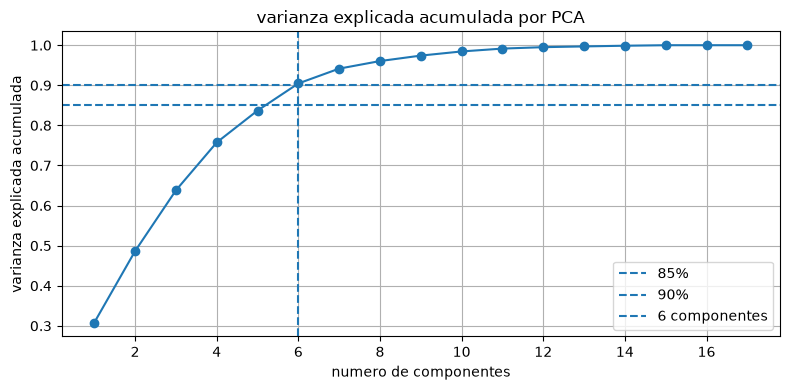

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(pca_summary["componente"], pca_summary["varianza_acumulada"], marker="o")
plt.axhline(0.85, linestyle="--", label="85%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.axvline(n_components_85, linestyle="--", label=f"{n_components_85} componentes")
plt.xlabel("numero de componentes")
plt.ylabel("varianza explicada acumulada")
plt.title("varianza explicada acumulada por PCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Conservaremos 6 componentes principales. Con ellos se supera el 85% y tambien el 90% de varianza explicada, por lo que se reduce la dimensionalidad sin perder demasiada informacion.

In [9]:
n_components_final = 6

pca = PCA(n_components=n_components_final, random_state=42)
X_pca = pca.fit_transform(X_prepared)

print(f"dimension preparada: {X_prepared.shape}")
print(f"dimension PCA: {X_pca.shape}")
print(f"varianza acumulada conservada: {pca.explained_variance_ratio_.sum()}")

dimension preparada: (20640, 17)
dimension PCA: (20640, 6)
varianza acumulada conservada: 0.9046117693234577


Para interpretar las primeras dimensiones, revisamos las variables con mayor carga absoluta en cada componente.

Una carga alta indica que esa variable influye mucho en la direccion del componente.

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i}" for i in range(1, n_components_final + 1)],
)

for component in ["PC1", "PC2", "PC3"]:
    top_loadings = (loadings[component].sort_values(key=lambda s: s.abs(), ascending=False).head(8).to_frame("loading"))
    print(f"variables mas influyentes en {component}:")
    display(top_loadings)

variables mas influyentes en PC1:


,loading
num__households,0.490501
num__total_bedrooms,0.488441
num__total_rooms,0.485038
num__population,0.471131
num__housing_median_age,-0.220287
num__longitude,0.077181
num__latitude,-0.074395
num__median_income,0.051148


variables mas influyentes en PC2:


,loading
num__rooms_per_household,0.557974
num__bedrooms_per_room,-0.423914
num__bedrooms_per_household,0.377654
num__latitude,0.336894
num__median_income,0.332653
num__longitude,-0.298896
num__housing_median_age,-0.143233
num__total_rooms,0.108164


variables mas influyentes en PC3:


,loading
num__longitude,0.607656
num__latitude,-0.600741
num__rooms_per_household,0.270590
num__median_income,0.261061
num__bedrooms_per_household,0.189342
num__bedrooms_per_room,-0.167228
cat__ocean_proximity_<1H OCEAN,0.136539
num__households,-0.104521


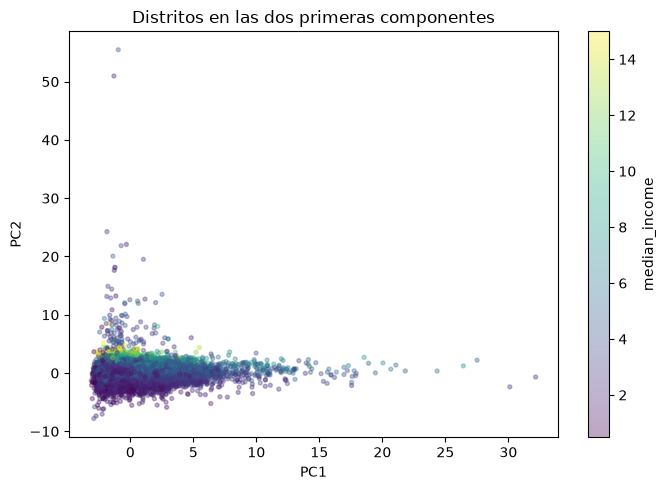

In [11]:
pca_2d = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "ocean_proximity": df["ocean_proximity"],
    "median_income": df["median_income"],
})

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pca_2d["PC1"],
    pca_2d["PC2"],
    c=pca_2d["median_income"],
    s=8,
    alpha=0.35,
    cmap="viridis",
)
plt.colorbar(scatter, label="median_income")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Distritos en las dos primeras componentes")
plt.tight_layout()
plt.show()

## Mision 3: Construccion de perfiles de distritos

Evaluaremos KMeans con distintos valores de `k`, tanto sobre la matriz preparada original como sobre la representacion PCA. Usaremos silhouette, donde mayor es mejor en general.

Usamos una muestra, porque calcularlo exactamente sobre todos los pares de observaciones es costoso.

In [12]:
clustering_results = []

for space_name, matrix in [("preparada", X_prepared), ("pca", X_pca)]:
    for k in range(2, 9):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(matrix)

        clustering_results.append({
            "espacio": space_name,
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": silhouette_score(
                matrix,
                labels,
                sample_size=5000,
                random_state=42,
            ),
        })

clustering_results = pd.DataFrame(clustering_results)
display(clustering_results.sort_values(["espacio", "k"]))

,espacio,k,inertia,silhouette
7,pca,2,192933.893013,0.390692
8,pca,3,158881.119711,0.296272
9,pca,4,139434.884197,0.299771
10,pca,5,127521.972156,0.261302
11,pca,6,109822.356878,0.294063
12,pca,7,96735.453063,0.260047
13,pca,8,89517.381364,0.235667
0,preparada,2,217871.262075,0.364014
1,preparada,3,183814.344000,0.251944
2,preparada,4,164346.415647,0.254436


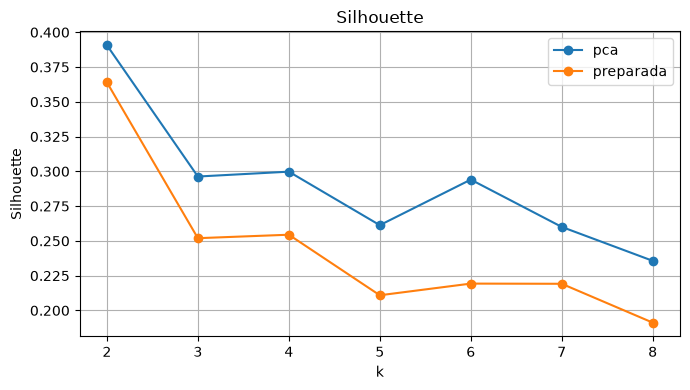

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

for space_name, subset in clustering_results.groupby("espacio"):
    ax.plot(
        subset["k"],
        subset["silhouette"],
        marker="o",
        label=space_name
    )

ax.set_title("Silhouette")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

Aunque `k=2` obtiene el mayor silhouette, entrega una separacion muy gruesa. Para comparar de forma mas concreta las dos alternativas pedidas por el enunciado, construiremos una solucion con `k=4` sobre:

- la matriz preparada original;
- la representacion reducida con PCA.

Luego seleccionaremos una solucion final considerando separacion, estabilidad e interpretabilidad.

In [14]:
final_k = 4

kmeans_prepared = KMeans(n_clusters=final_k, random_state=42, n_init=10)
clusters_prepared = kmeans_prepared.fit_predict(X_prepared)

kmeans_pca = KMeans(n_clusters=final_k, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

comparison_k4 = clustering_results[
    (clustering_results["k"] == final_k)
    & (clustering_results["espacio"].isin(["preparada", "pca"]))
].sort_values("espacio").reset_index(drop=True)

cluster_sizes_comparison = pd.DataFrame({
    "preparada": pd.Series(clusters_prepared).value_counts().sort_index(),
    "pca": pd.Series(clusters_pca).value_counts().sort_index(),
}).rename_axis("cluster")

print("Comparacion de metricas para k=4:")
display(comparison_k4)

print("Tamanos de clusters para k=4:")
display(cluster_sizes_comparison)

Comparacion de metricas para k=4:


,espacio,k,inertia,silhouette
0,pca,4,139434.884197,0.299771
1,preparada,4,164346.415647,0.254436


Tamanos de clusters para k=4:


,preparada,pca
cluster,,
0,8236,10648
1,1662,1679
2,10666,76
3,76,8237


La alternativa sobre PCA tiene mejor silhouette para `k=4` que la alternativa sobre la matriz preparada original. Ademas, trabajar en PCA reduce ruido y redundancia entre variables derivadas y variables originales.

Por eso seleccionamos como solucion final `k=4` sobre la representacion PCA. También se recomienda hacer el método del codo.

In [15]:
final_space = "pca"
kmeans_final = kmeans_pca
final_clusters = clusters_pca

df_profiles = df.copy()
df_profiles["cluster"] = final_clusters

print(f"solucion final: {final_space} con k = {final_k}")
print("clusters finales:")
display(df_profiles["cluster"].value_counts().sort_index().rename("n_distritos"))

solucion final: pca con k = 4
clusters finales:


cluster
0    10648
1     1679
2       76
3     8237
Name: n_distritos, dtype: int64

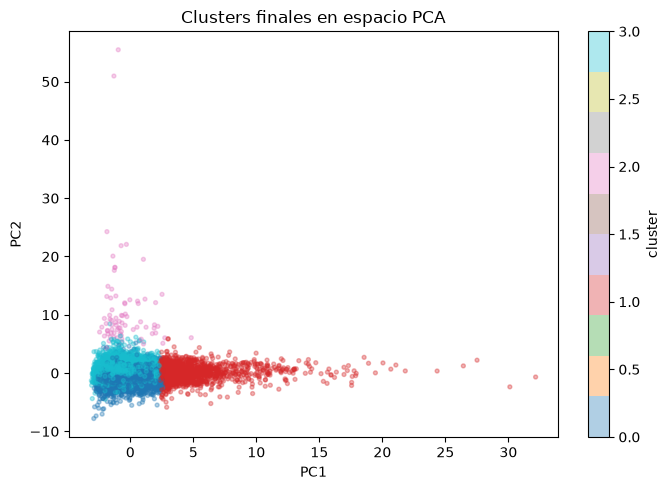

In [16]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_clusters,
    s=8,
    alpha=0.35,
    cmap="tab10",
)
plt.colorbar(scatter, label="cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters finales en espacio PCA")
plt.tight_layout()
plt.show()

## Mision 4: Caracterizacion territorial y socioeconomica

In [17]:
profile_numeric_vars = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "bedrooms_per_household",
    "median_house_value",
]

profile_summary = (df_profiles.groupby("cluster")[profile_numeric_vars].mean().round(2))

display(profile_summary)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,bedrooms_per_household,median_house_value
cluster,,,,,,,,,,,,,
0,-118.01,33.90,29.82,2159.02,454.31,1269.68,427.14,3.90,5.16,0.22,3.08,1.07,215137.63
1,-119.16,35.25,16.49,7821.36,1562.35,3979.44,1428.46,4.25,5.57,0.21,2.81,1.10,222011.42
2,-119.37,37.66,18.70,3232.53,645.04,296.17,121.21,3.37,31.98,0.21,2.50,6.70,162581.59
3,-121.68,37.93,29.68,2189.53,435.27,1116.70,407.27,3.76,5.50,0.20,3.12,1.08,193469.13


Crosstab, muy recomendado para este tipo de cosas.

In [18]:
ocean_distribution = pd.crosstab(
    df_profiles["cluster"],
    df_profiles["ocean_proximity"],
    normalize="index",
).round(3)

display(ocean_distribution)

ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
cluster,,,,,
0,0.649,0.193,0.0,0.000,0.158
1,0.463,0.356,0.0,0.079,0.102
2,0.000,0.987,0.0,0.000,0.013
3,0.175,0.465,0.0,0.262,0.098


In [19]:
cluster_names = {
    0: "Norte/interior y bahia de valor medio",
    1: "Distritos grandes de expansion urbana",
    2: "Costa sur y zonas cercanas al oceano",
    3: "Distritos atipicos de baja densidad",
}

profile_names = pd.Series(cluster_names, name="nombre_perfil")
display(profile_names)

0    Norte/interior y bahia de valor medio
1    Distritos grandes de expansion urbana
2     Costa sur y zonas cercanas al oceano
3      Distritos atipicos de baja densidad
Name: nombre_perfil, dtype: str

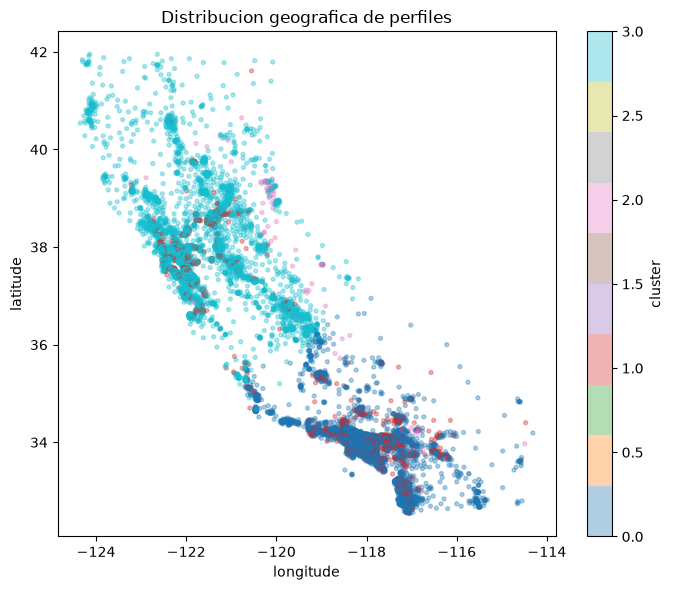

In [20]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    df_profiles["longitude"],
    df_profiles["latitude"],
    c=df_profiles["cluster"],
    s=8,
    alpha=0.35,
    cmap="tab10",
)
plt.colorbar(scatter, label="cluster")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Distribucion geografica de perfiles")
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

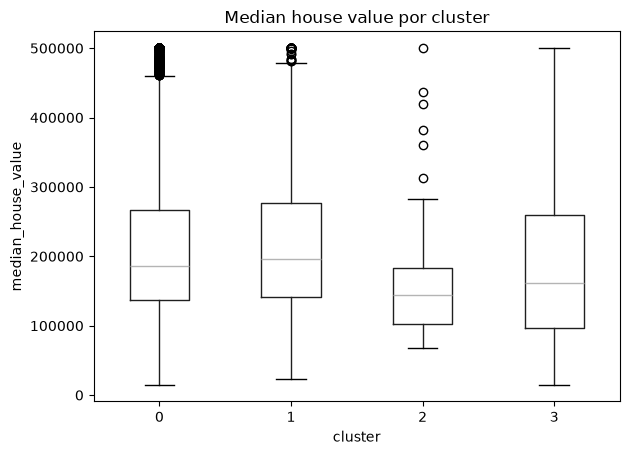

In [21]:
plt.figure(figsize=(8, 4))
df_profiles.boxplot(column="median_house_value", by="cluster", grid=False)
plt.title("Median house value por cluster")
plt.suptitle("")
plt.xlabel("cluster")
plt.ylabel("median_house_value")
plt.tight_layout()
plt.show()

Interpretacion resumida de los perfiles:

- Cluster 0: distritos mas al norte, con mayor presencia relativa de zonas `INLAND` y `NEAR BAY`, valor habitacional medio y viviendas de escala intermedia.
- Cluster 1: distritos grandes, mas nuevos, con muchos hogares y poblacion; representan zonas de expansion urbana.
- Cluster 2: distritos mas asociados a la costa sur y a `<1H OCEAN`, con mayor valor promedio de vivienda.
- Cluster 3: grupo pequeno y atipico, principalmente `INLAND`, con valores muy altos de habitaciones por hogar; conviene interpretarlo como outliers estructurales.

## Mision 5: Evaluacion e interpretacion de resultados

Usamos ARI para ver la estabilidad de la agrupación. 

In [22]:
stability_rows = []

for k in [3, 4, 5]:
    labels_by_seed = []

    for seed in [1, 2, 3, 4, 5]:
        labels = KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(X_pca)
        labels_by_seed.append(labels)

    ari_values = []
    for i in range(len(labels_by_seed)):
        for j in range(i + 1, len(labels_by_seed)):
            ari_values.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))

    stability_rows.append({
        "k": k,
        "ARI_promedio": np.mean(ari_values),
        "ARI_min": np.min(ari_values),
        "ARI_max": np.max(ari_values),
    })

stability_results = pd.DataFrame(stability_rows)
display(stability_results)

,k,ARI_promedio,ARI_min,ARI_max
0,3,0.999848,0.999669,1.000000
1,4,0.999270,0.998743,0.999803
2,5,0.784209,0.651653,0.999819


In [23]:
distances_to_centroid = kmeans_final.transform(X_pca).min(axis=1)
df_profiles["distance_to_centroid"] = distances_to_centroid

hard_cases = (
    df_profiles
    .sort_values("distance_to_centroid", ascending=False)
    [["cluster", "longitude", "latitude", "median_income", "rooms_per_household", "population_per_household", "median_house_value", "ocean_proximity", "distance_to_centroid"]]
    .head(10)
)

print("Observaciones mas alejadas de su centroide:")
display(hard_cases)

Observaciones mas alejadas de su centroide:


,cluster,longitude,latitude,median_income,rooms_per_household,population_per_household,median_house_value,ocean_proximity,distance_to_centroid
19006,3,-121.98,38.32,10.2264,3.166667,1243.333333,137500.0,INLAND,119.480778
1979,2,-120.08,38.80,4.6250,132.533333,2.400000,162500.0,INLAND,69.749398
1914,2,-120.10,38.91,1.8750,141.909091,2.727273,500001.0,INLAND,59.122472
3364,3,-120.51,40.41,5.5179,5.142857,599.714286,67500.0,INLAND,57.511756
16669,3,-120.70,35.32,4.2639,9.076923,502.461538,350000.0,NEAR OCEAN,48.375067
9880,1,-121.79,36.64,2.3087,5.364518,4.696810,118800.0,<1H OCEAN,28.337967
15360,1,-117.42,33.35,2.5729,5.270497,7.482072,134400.0,<1H OCEAN,26.068263
13139,1,-121.44,38.43,4.9516,7.338559,3.043113,153700.0,INLAND,23.424293
13034,3,-121.15,38.69,6.1359,8.275862,230.172414,225000.0,INLAND,22.403936
10309,1,-117.74,33.89,7.4947,7.311043,3.106957,366300.0,<1H OCEAN,21.999767


In [24]:
quality_final = clustering_results[
    (clustering_results["espacio"] == final_space)
    & (clustering_results["k"] == final_k)
]

print("Metricas de la solucion final:")
display(quality_final)

Metricas de la solucion final:


,espacio,k,inertia,silhouette
9,pca,4,139434.884197,0.299771


Conclusion:

La estructura encontrada distingue grupos relacionados con ubicacion, proximidad al oceano, escala habitacional, ingreso y densidad. La solucion final con PCA y `k=4` no maximiza solamente una metrica, sino que equilibra separacion e interpretabilidad.

La estabilidad es alta para `k=3` y `k=4` (gracias al ARI vemos que valores cercanos a 1 confirman esto), lo que indica que los perfiles principales son relativamente consistentes frente a cambios de inicializacion. Sin embargo, existen observaciones dificiles de clasificar, especialmente distritos atipicos con razones habitacionales extremas.

Una limitacion importante es que KMeans asume grupos aproximadamente 'esfericos' en el espacio transformado. Ademas, los datos son agregados por distrito, por lo que los perfiles pueden ocultar diferencias internas entre viviendas individuales. `median_house_value` ayuda a interpretar los grupos, pero no explica por si sola su formacion, ya que no fue usada para construirlos.